# Filling Gaps with Satellite images

In the previous tutorials we discussed the issue of monitoring data spatially under-representing a city. We specifically saw how Delhi, with India's densest monitoring network, covers only [35% of its geographical area](https://www.indiaspend.com/pollution/two-thirds-of-delhi-does-not-have-reliable-air-quality-data-972167).<br>
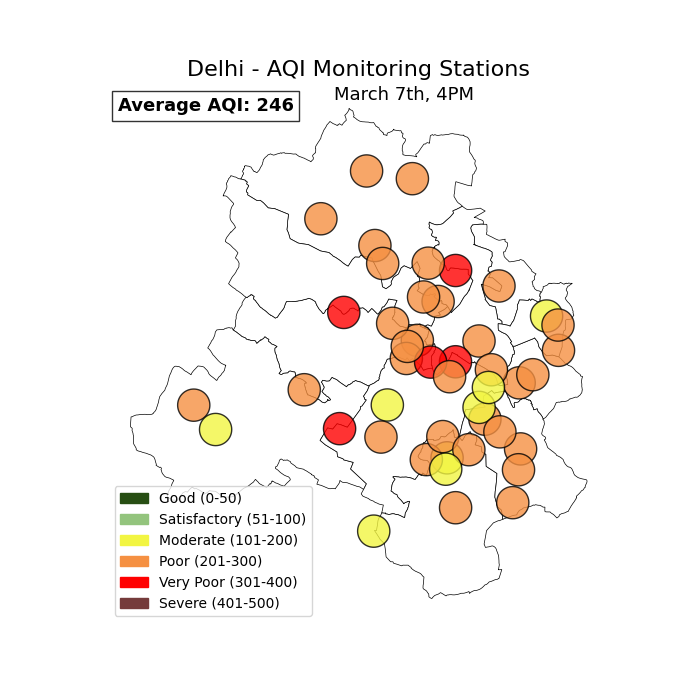<br>
In this tutorial we'll learn how to fill gaps. There are several methods to fill these gaps. We'll use satellite images from `SENTINEL-5P TROPOMI Sensor` to fill gaps in this tutorial. We'll also learn about limitations of this method. 

## About TROPOMI

TROPOspheric Monitoring Instrument (TROPOMI) is a sensor aboard a satellite part of the European Space Agency's [Sentinel-5P](https://dataspace.copernicus.eu/explore-data/data-collections/sentinel-data/sentinel-5p) mission. The primary goal of TROPOMI is to provide daily global observations of key atmospheric constituents related to monitoring and forecasting air quality, the ozone layer, and climate change.

The two crucial parameters to note when working with a satellite data are `spatial resolution` and `temporal resolution`. 

1. TROPOMI has daily observations of several pollutants like `NO2`, `O3`, `CO`, `HCHO` and `SO2`. The `temporal resolution` is thus: 24 hours.
2. `spatial resolution` is simply the size of the pixel in the stallite image. TROPOMI's images has a pixel size of `~3.5 x 5.5 km`.


## Downloading TROPOMI images from the source

There are many satellite data providers who improve upon the basic TROPOMI layers. We'll start with learning how to get TROPOMI images from the source: [Copernicus dataspace](https://browser.dataspace.copernicus.eu/). It is recommended to login to use all features of the portal.

We'll download `NO2` pollutant image. `NO2` pollutant is more reliable than other pollutants from TROPOMI. `NO2` has a lifetime of about a day. TROPOMI gives one picture of any region per day. So, each day's `NO2` measurement can be interpreted as pollution on that day.

After logging into to the [Copernicus dataspace], it is straight forward to download `NO2` pollutant image.
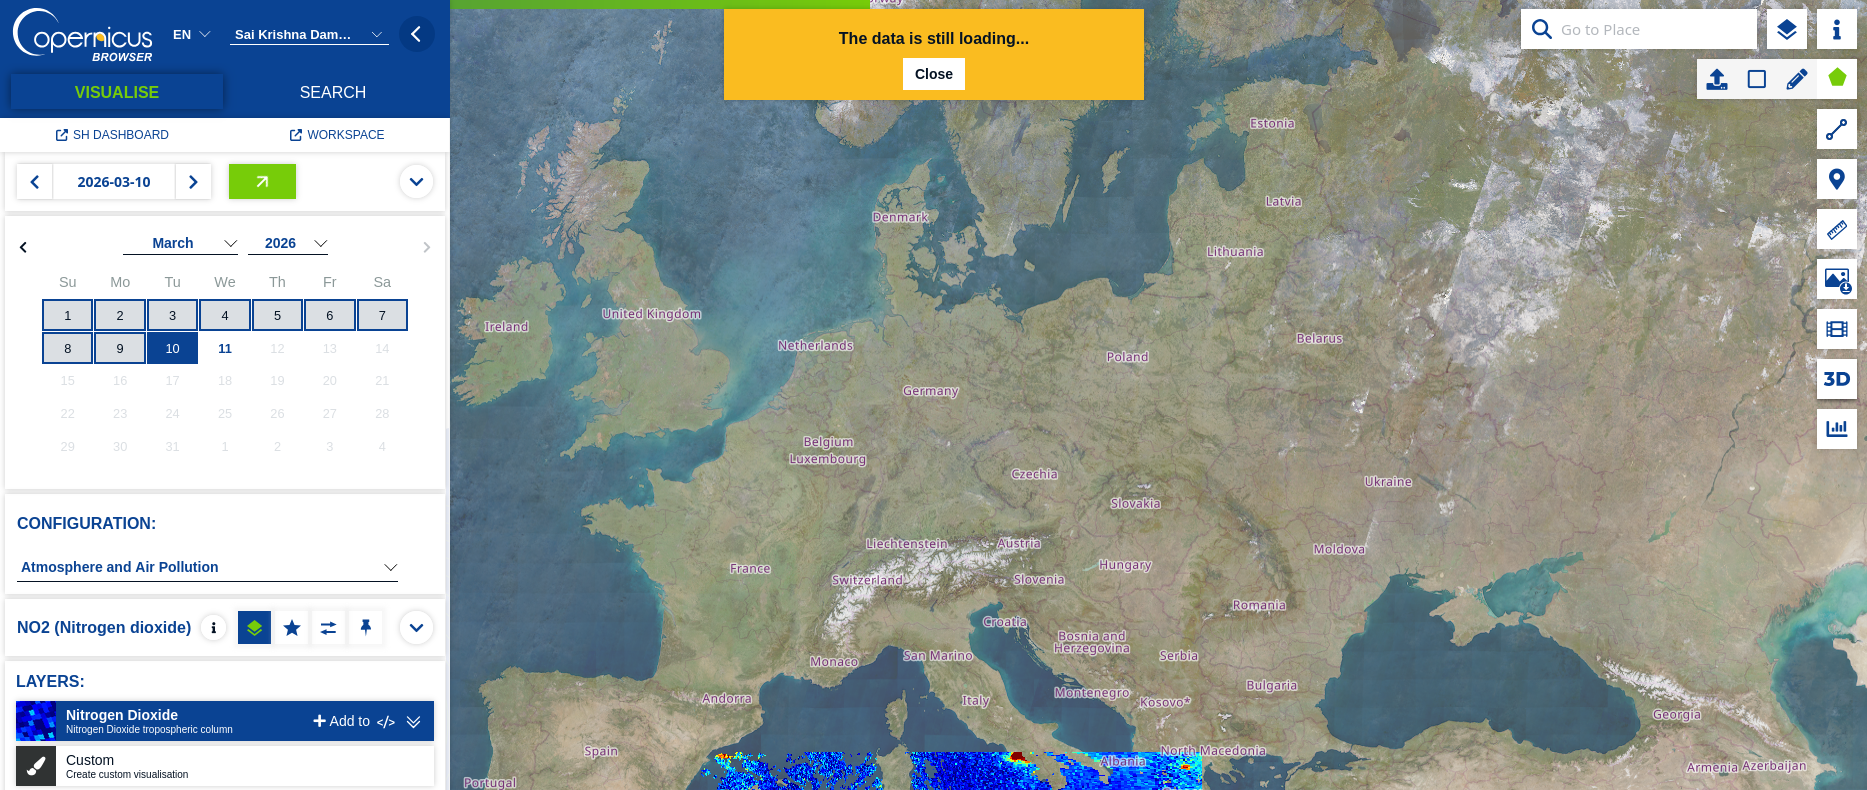

On the left panel:
1. Select the day
2. Select Configuration as `Atmosphere and Air Pollution`
3. Choose `NO2` Layer

On the right panel:
1.  Create an area of interest. You can either draw directly on the map, or upload airshed's polygon in the form of `KML` or `GEOJSON` file. For this tutorial, I uploaded the Delhi state boundary.
2.  Click on download. You can download the image in Basic `JPG/PNG` formats or in Analytical `TIF` formats. `TIF` images can be analysed using geospatial softwares like `QGIS`, `rasterio` etc.<br>
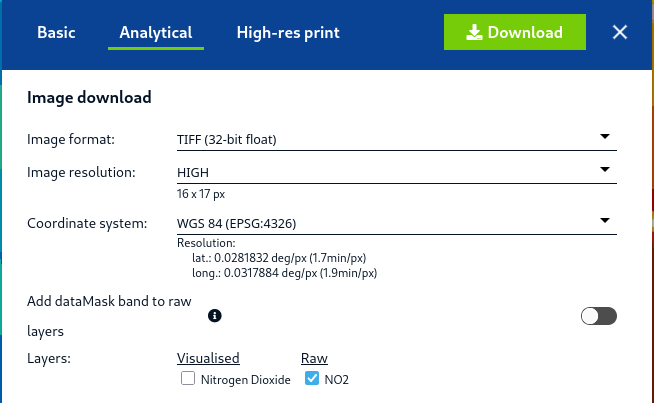

`Raw NO2` are the pixel level measurement of NO2. TROPOMI uses a unit of `mol/m2`. We'll use the `Raw NO2` file to plot the satellite image of Delhi. This visualisation is also part of our [Air Quality Visuals Course](https://urbanemissionsinfo.github.io/AirQualityVisuals/): [Plotting Satellite images](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Plotting_SatelliteImages.html)

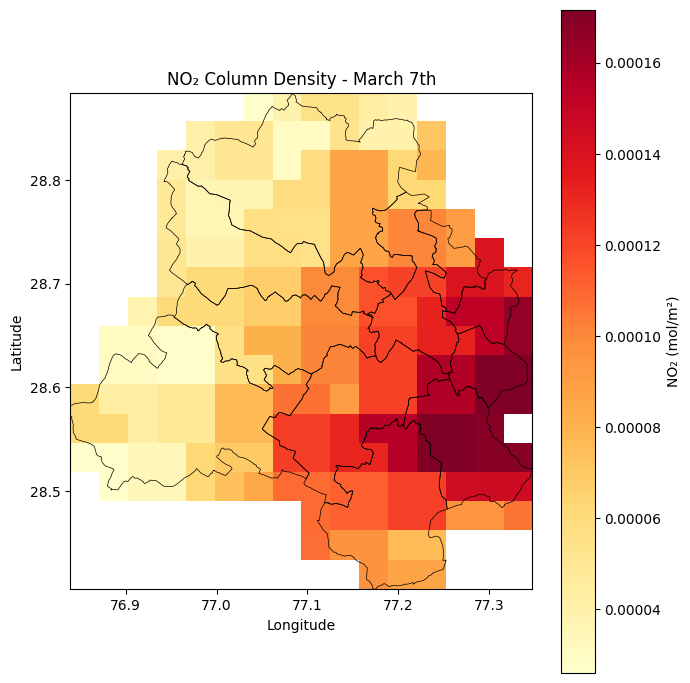

In [3]:
#| code-fold: true
#| code-summary: "Show hidden code that plots the Raw NO2 TIFF file"

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.plot import show
import geopandas as gpd

# Load TIFF
tif_path = "data/2026-03-07-00_00_2026-03-07-23_59_Sentinel-5P_NO2_NO2_(Raw).tiff"
with rasterio.open(tif_path) as src:
    no2 = src.read(1)                        # first band
    no2 = np.where(no2 == src.nodata, np.nan, no2)  # mask nodata
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    crs = src.crs

# Load admin boundaries — reproject to match raster CRS
delhi_districts = gpd.read_file('data/DELHI_DISTRICTS.geojson').to_crs(crs)
delhi_districts.head()

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(
    no2,
    extent=extent,
    cmap='YlOrRd',
    origin='upper',
    vmin=np.nanpercentile(no2, 2),   # clip outliers
    vmax=np.nanpercentile(no2, 98),
)

# Admin boundary overlay
delhi_districts.boundary.plot(ax=ax, linewidth=0.5, color='black')

plt.colorbar(im, ax=ax, label='NO₂ (mol/m²)')
ax.set_title('NO₂ Column Density - March 7th')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
#plt.savefig('no2_map.png', dpi=150, bbox_inches='tight')
plt.show()

Thus we have filled the gaps in NO2 monitoring using TROPOMI's NO2 data in Delhi.

## Limitations of Satellite images
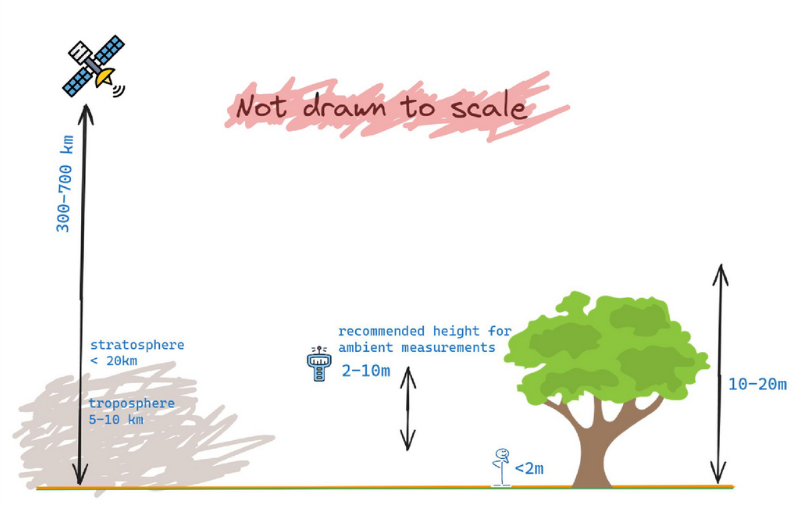

While satellite images help us get pollutant concentration in areas where there are no monitoring stations, there are a few limitations in relying completely on satellite images alone:

1. Satellite images give the value for the entire vertical column above the ground, while we are generally interested in the ambient measurements (2-10m height), where we breathe air.
2. TROPOMI gives data of a region once per day, typically at the same time around `~13:30 local time`. It might thus under-bias short-lived pollutants if the satellite doesn't pass over the region when the pollutant is live. For example, if the stubble in farms are burnt in the evenings, they could go un-detected. For this reason, [Supreme Court of India asked the government to purchase data from geo-stationary satellites to monitor farm fires](https://www.business-standard.com/india-news/sc-asks-govt-to-procure-data-on-farm-fires-from-geo-stationary-satellites-124111801174_1.html)

Nevertheless, combining satellite data with ground-monitoring data and modelling data allows us to get a better understanding of air quality in a city.

## Summary

In this tutorial, we learnt that a city's air quality monitoring network alone would result in a lot of gaps spatially. We then learnt to fill these gaps using satellite images - that of TROPOMI. We also learnt the limitations of satellite images. 

There are many other ways to access TROPOMI data:

1. You can use [Google Earth Engine (GEE)](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_NO2). This code will help you to visualise and download TROPOMI data of any pollutant of any city/region: [TROPOMI Pollutants GEE Code](https://code.earthengine.google.com/53995a177b50a718b9455f651cae0bdf)
2. There are applications on Google Earth Engine like [Tropomi Explorer](jstnbraaten.users.earthengine.app/view/tropomi-explorer)
3. You could download the entire globe's TROPOMI data in the form of `NetCDF` files from here: [Radiant Earth STAC Browser](https://radiantearth.github.io/stac-browser/#/external/data-portal.s5p-pal.com/api/s5p-l3?.language=en)